In [1]:
import sys
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
sys.path.append('../src/')
import regression_models as rm

I0000 00:00:1780406667.394234 1392379 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
# training dataset
raw_data = '../data/processed/2020_joined_norm_jeong.csv'
raw_df = pd.read_csv(raw_data)
# fill nan as 0
raw_df = raw_df.fillna(0)
training_data = raw_df.iloc[:, 6:]
target_data = raw_df.loc[:, 'candidatevotes_dem'] / raw_df.loc[:, 'totalvotes']

In [4]:
# 70/30 TTS and fixed random_state for dev
tts = train_test_split(training_data.values,
                       target_data.values,
                       test_size=0.3,
                       random_state=1776)
X_train, X_test, y_train, y_test = tts
feature_size = X_train.shape[-1]

In [5]:
simple_regressor = rm.simple_regressor(feature_size, 0.2)
low_emb_regressor = rm.embedded_regressor(feature_size, 0.2)
mid_emb_regressor = rm.more_embedded_regressor(feature_size, 0.2)
hi_emb_regressor = rm.hi_embedded_regressor(feature_size, 0.2)
# for training iterations
model_and_paths = {
    'simple': {
        'model': simple_regressor,
        'path': '../models/simple_regressor.keras'
    },
    'low': {
        'model': low_emb_regressor,
        'path': '../models/low_emb_regressor.keras'
    },
    'mid': {
        'model': mid_emb_regressor,
        'path': '../models/mid_emb_regressor.keras'
    },
    'high': {
        'model': hi_emb_regressor,
        'path': '../models/hi_emb_regressor.keras'
    }
}

/home/yung/miniconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780406670.336597 1392379 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5320 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
# training loop
training_history = {}
epochs = 2500
for model_type, params in model_and_paths.items():
    hist = rm.compile_train_checkpoint(params['model'],
                                       *tts,
                                       epochs=epochs,
                                       filepath=params['path'],
                                       learning_rate=0.001)
    # save history
    training_history[model_type] = hist



I0000 00:00:1780406671.672893 1392440 service.cc:153] XLA service 0x7f7980035770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780406671.672910 1392440 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1780406671.689075 1392440 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780406671.789902 1392440 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1780406671.816167 1392440 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2011__.16
I0000 00:00:1780406671.839605 1392440 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I00

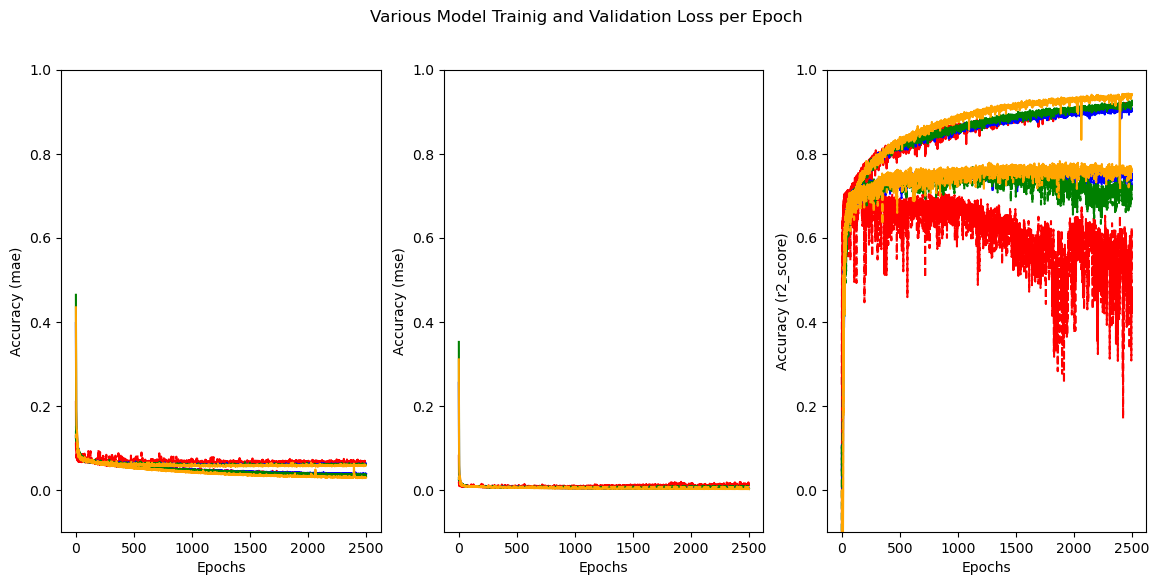

In [7]:
# visualize history
x = list(range(epochs))
fig, ax = plt.subplots(1,3, figsize=(14, 6))
colors = ['red', 'blue', 'green', 'orange']
for i, acc_type in zip(range(3), ['mae', 'mse', 'r2_score']):
    for model_type, color in zip(training_history.keys(), colors):
        _hist = training_history[model_type].history
        ax[i].plot(x, _hist[acc_type], label=acc_type, color=color)
        ax[i].plot(x, _hist[f'val_{acc_type}'], label=f'{acc_type}-val', color=color, linestyle='--')
        ax[i].set_ylim(-0.1, 1)
        ax[i].set_xlabel('Epochs')
        ax[i].set_ylabel(f'Accuracy ({acc_type})')
        #ax[i].legend()
plt.suptitle('Various Model Trainig and Validation Loss per Epoch')
plt.show()

In [8]:
# calculate metric
R2_metric = keras.metrics.R2Score()
MSE_metric = tf.keras.metrics.MeanSquaredError()

# get metric after training
for model_type, params in model_and_paths.items():
    _model = params['model']
    _model.load_weights(params['path'])
    _pred = _model.predict(X_test)
    R2_metric.update_state(y_test, _pred)
    R2_score = R2_metric.result()
    MSE_metric.update_state(y_test, _pred)
    mse_score = MSE_metric.result()
    print(f'{model_type} model best result')
    print('R2 Score: ', R2_score)
    print('MSE Score: ', mse_score) 

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
simple model best result
R2 Score:  tf.Tensor(0.5125065, shape=(), dtype=float32)
MSE Score:  tf.Tensor(0.0122964075, shape=(), dtype=float32)
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
low model best result
R2 Score:  tf.Tensor(0.6329477, shape=(), dtype=float32)
MSE Score:  tf.Tensor(0.009258431, shape=(), dtype=float32)
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
mid model best result
R2 Score:  tf.Tensor(0.66021717, shape=(), dtype=float32)
MSE Score:  tf.Tensor(0.008570588, shape=(), dtype=float32)
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
high model best result
R2 Score:  tf.Tensor(0.68605024, shape=(), dtype=float32)
MSE Score:  tf.Tensor(0.0079189865, shape=(), dtype=float32)


In [9]:
simple_regressor_nodrop = rm.simple_regressor(feature_size, 0.0)
low_emb_regressor_nodrop = rm.embedded_regressor(feature_size, 0.0)
mid_emb_regressor_nodrop = rm.more_embedded_regressor(feature_size, 0.0)
hi_emb_regressor_nodrop = rm.hi_embedded_regressor(feature_size, 0.0)
# for training iterations
model_and_paths_nodrop = {
    'simple': {
        'model': simple_regressor_nodrop,
        'path': '../models/simple_regressor_nodrop.keras'
    },
    'low': {
        'model': low_emb_regressor_nodrop,
        'path': '../models/low_emb_regressor_nodrop.keras'
    },
    'mid': {
        'model': mid_emb_regressor_nodrop,
        'path': '../models/mid_emb_regressor_nodrop.keras'
    },
    'high': {
        'model': hi_emb_regressor_nodrop,
        'path': '../models/hi_emb_regressor_nodrop.keras'
    }
}

In [10]:
# training loop
training_history_nodrop = {}
epochs = 4000
for model_type, params in model_and_paths_nodrop.items():
    hist = rm.compile_train_checkpoint(params['model'],
                                       *tts,
                                       epochs=epochs,
                                       filepath=params['path'],
                                       learning_rate=0.001)
    # save history
    training_history_nodrop[model_type] = hist



I0000 00:00:1780408429.812674 1392436 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5993885__.15
I0000 00:00:1780408429.819704 1392436 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780408430.375689 1953918 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_4', 148 bytes spill stores, 148 bytes spill loads

I0000 00:00:1780408431.129446 1392440 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5993885__.15
I0000 00:00:1780409096.237996 1392436 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8327993__.16
I0000 00:00:1780409096.246372 1392436 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently

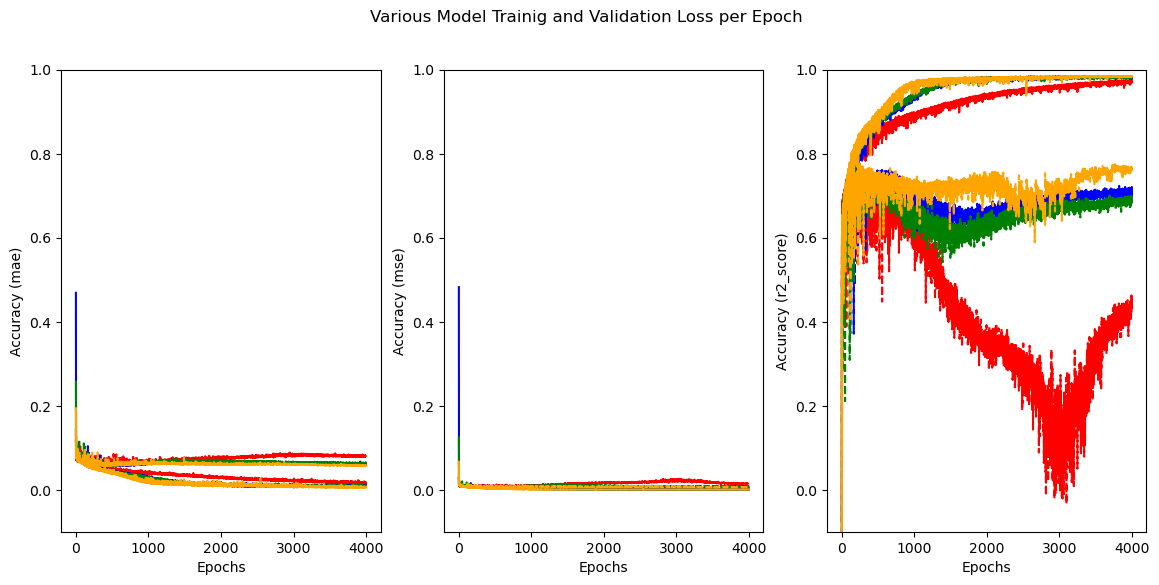

In [11]:
# visualize history
x = list(range(epochs))
fig, ax = plt.subplots(1,3, figsize=(14, 6))
colors = ['red', 'blue', 'green', 'orange']
for i, acc_type in zip(range(3), ['mae', 'mse', 'r2_score']):
    for model_type, color in zip(training_history_nodrop.keys(), colors):
        _hist = training_history_nodrop[model_type].history
        ax[i].plot(x, _hist[acc_type], label=acc_type, color=color)
        ax[i].plot(x, _hist[f'val_{acc_type}'], label=f'{acc_type}-val', color=color, linestyle='--')
        ax[i].set_ylim(-0.1, 1)
        ax[i].set_xlabel('Epochs')
        ax[i].set_ylabel(f'Accuracy ({acc_type})')
        #ax[i].legend()
plt.suptitle('Various Model Trainig and Validation Loss per Epoch')
plt.show()

In [12]:
# calculate metric
R2_metric = keras.metrics.R2Score()
MSE_metric = tf.keras.metrics.MeanSquaredError()

# get metric after training
for model_type, params in model_and_paths.items():
    _model = params['model']
    _model.load_weights(params['path'])
    _pred = _model.predict(X_test)
    R2_metric.update_state(y_test, _pred)
    R2_score = R2_metric.result()
    MSE_metric.update_state(y_test, _pred)
    mse_score = MSE_metric.result()
    print(f'{model_type} model best result')
    print('R2 Score: ', R2_score)
    print('MSE Score: ', mse_score) 

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
simple model best result
R2 Score:  tf.Tensor(0.5125065, shape=(), dtype=float32)
MSE Score:  tf.Tensor(0.0122964075, shape=(), dtype=float32)
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
low model best result
R2 Score:  tf.Tensor(0.6329477, shape=(), dtype=float32)
MSE Score:  tf.Tensor(0.009258431, shape=(), dtype=float32)
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
mid model best result
R2 Score:  tf.Tensor(0.66021717, shape=(), dtype=float32)
MSE Score:  tf.Tensor(0.008570588, shape=(), dtype=float32)
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
high model best result
R2 Score:  tf.Tensor(0.68605024, shape=(), dtype=float32)
MSE Score:  tf.Tensor(0.0079189865, shape=(), dtype=float32)


## OLD

In [7]:
label_data = '../data/Raw/countypres_2000-2024.csv'
label_data_df = pd.read_csv(label_data)

In [9]:
label_data_df.head()


,state,county_name,year,state_po,county_fips,office,candidate,party,candidatevotes,totalvotes,version,mode
0,ALABAMA,AUTAUGA,2024,AL,1001.0,US PRESIDENT,OTHER,OTHER,293.0,28281,20260225,TOTAL
1,ALABAMA,AUTAUGA,2024,AL,1001.0,US PRESIDENT,CHASE OLIVER,LIBERTARIAN,65.0,28281,20260225,TOTAL
2,ALABAMA,AUTAUGA,2024,AL,1001.0,US PRESIDENT,KAMALA D HARRIS,DEMOCRAT,7439.0,28281,20260225,TOTAL
3,ALABAMA,AUTAUGA,2024,AL,1001.0,US PRESIDENT,DONALD J TRUMP,REPUBLICAN,20484.0,28281,20260225,TOTAL
4,ALABAMA,BALDWIN,2024,AL,1003.0,US PRESIDENT,OTHER,OTHER,1276.0,122249,20260225,TOTAL


In [ ]:
# training dataset
raw_data = '../data/processed/2020_joined_norm_jeong.csv'
raw_df = pd.read_csv(raw_data)
# fill nan as 0
raw_df = raw_df.fillna(0)
training_data = raw_df.iloc[:, 6:]
target_data = raw_df.loc[:, 'candidatevotes_dem'] / raw_df.loc[:, 'totalvotes']

In [3]:
# preview data
print('Training Dataset: ', training_data.shape)

Training Dataset:  (2305, 146)


In [4]:
# 70/30 TTS and fixed random_state for dev
tts = train_test_split(training_data.values,
                       target_data.values,
                       test_size=0.3,
                       random_state=1776)
X_train, X_test, y_train, y_test = tts

In [5]:
X_train.shape

(1613, 146)

In [7]:
feature_size = X_train.shape[-1]
# single hidden layer
regression_model = tf.keras.Sequential([
    layers.Dense(feature_size, input_shape=(feature_size,)),
    # softplus activation to keep positive
    layers.Dense(feature_size, activation='softplus'),
    # regreesion layear, no activation
    layers.Dense(1)
])

regression_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='mse'
)


In [8]:
# callback for saving weights with validation
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='../models/best_nn_linear_regression.h5',
    monitor='val_accuracy', # use validation as monitoring accuracy
    save_best_only=True,
    mode='max'              
)

training_history = regression_model.fit(
    X_train,
    y_train,
    epochs = 2000,
    verbose = 0,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint_callback]
)

2026-05-27 11:48:01.147706: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
/Users/yung/.local/share/mamba/envs/tf_env/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


In [9]:
# load best model for metric
regression_model.load_weights('../models/best_nn_linear_regression.h5',)
pred = regression_model.predict(X_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [10]:
R2_metric = keras.metrics.R2Score()
R2_metric.update_state(y_test, pred)
R2_score = R2_metric.result()
MSE_metric = tf.keras.metrics.MeanSquaredError()
MSE_metric.update_state(y_test, pred)
mse_score = MSE_metric.result()
# basic linear regression achieved R2 0.3679282597984309
# SVM Regression achieved R2 0.7614698877080794
print('R2 Score: ', R2_score)
print('MSE Score: ', mse_score)

R2 Score:  tf.Tensor(0.7284051, shape=(), dtype=float32)
MSE Score:  tf.Tensor(0.006850635, shape=(), dtype=float32)


In [9]:
training_history.history

{'loss': [0.138778954744339,
  0.13368673622608185,
  0.13335378468036652,
  0.13327744603157043,
  0.1333799660205841,
  0.1332789808511734,
  0.13324372470378876,
  0.13325965404510498,
  0.13329391181468964,
  0.1333622932434082,
  0.1333107352256775,
  0.1332564800977707,
  2.157991409301758,
  0.1357322484254837,
  0.1369675099849701,
  0.1369674801826477,
  0.1369674950838089,
  0.1369674950838089,
  0.1369674950838089,
  0.1369675099849701,
  0.1369674950838089,
  0.1369674950838089,
  0.1369675099849701,
  0.1369675099849701,
  0.1369675099849701,
  0.1369674950838089,
  0.1369674950838089,
  0.1369675099849701,
  0.1369674801826477,
  0.1369674950838089,
  0.1369675099849701,
  0.1369674950838089,
  0.1369675099849701,
  0.1369675099849701,
  0.1369674950838089,
  0.1369674950838089,
  0.1369674950838089,
  0.1369674801826477,
  0.1369675099849701,
  0.1369675248861313,
  0.1369674950838089,
  0.1369674950838089,
  0.1369675099849701,
  0.1369674801826477,
  0.1369674801826477

In [14]:
# two hidden layer with compressing embedding space by half
comp_reg_model = tf.keras.Sequential([
    layers.Dense(feature_size, input_shape=(feature_size,)),
    # softplus activation to keep positive
    layers.Dense(int(feature_size/2), activation='softplus'),
    layers.Dense(int(feature_size/2), activation='softplus'),
    # regreesion layear, no activation
    layers.Dense(1)
])

comp_reg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='mse'
)

# callback for saving weights with validation
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='../models/best_nn_comp_linear_regression.h5',
    monitor='val_accuracy', # use validation as monitoring accuracy
    save_best_only=True,
    mode='max'              
)

comp_training_history = comp_reg_model.fit(
    X_train,
    y_train,
    epochs = 2000,
    verbose = 0,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint_callback]
)

/Users/yung/.local/share/mamba/envs/tf_env/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


In [17]:
# load best model for metric
comp_reg_model.load_weights('../models/best_nn_comp_linear_regression.h5',)
comp_pred = comp_reg_model.predict(X_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [18]:
R2_metric = keras.metrics.R2Score()
R2_metric.update_state(y_test, comp_pred)
R2_score = R2_metric.result()
MSE_metric = tf.keras.metrics.MeanSquaredError()
MSE_metric.update_state(y_test, comp_pred)
mse_score = MSE_metric.result()
# basic linear regression achieved R2 0.3679282597984309
# SVM Regression achieved R2 0.7614698877080794
print('R2 Score: ', R2_score)
print('MSE Score: ', mse_score)

R2 Score:  tf.Tensor(0.7409699, shape=(), dtype=float32)
MSE Score:  tf.Tensor(0.006533704, shape=(), dtype=float32)


In [19]:
# more layers!
more_reg_model = tf.keras.Sequential([
    layers.Dense(feature_size, input_shape=(feature_size,)),
    # softplus activation to keep positive
    # compress and expand hidden space
    layers.Dense(feature_size, activation='softplus'),
    layers.Dense(int(feature_size/2), activation='softplus'),
    layers.Dense(feature_size, activation='softplus'),
    # regreesion layear, no activation
    layers.Dense(1)
])

more_reg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='mse'
)

# callback for saving weights with validation
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='../models/best_nn_more_linear_regression.h5',
    monitor='val_accuracy', # use validation as monitoring accuracy
    save_best_only=True,
    mode='max'              
)

more_training_history = more_reg_model.fit(
    X_train,
    y_train,
    epochs = 2000,
    verbose = 0,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint_callback]
)

/Users/yung/.local/share/mamba/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/yung/.local/share/mamba/envs/tf_env/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


In [20]:
# load best model for metric
more_reg_model.load_weights('../models/best_nn_more_linear_regression.h5',)
more_pred = more_reg_model.predict(X_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [21]:
R2_metric = keras.metrics.R2Score()
R2_metric.update_state(y_test, more_pred)
R2_score = R2_metric.result()
MSE_metric = tf.keras.metrics.MeanSquaredError()
MSE_metric.update_state(y_test, more_pred)
mse_score = MSE_metric.result()
# basic linear regression achieved R2 0.3679282597984309
# SVM Regression achieved R2 0.7614698877080794
print('R2 Score: ', R2_score)
print('MSE Score: ', mse_score)

R2 Score:  tf.Tensor(0.7544497, shape=(), dtype=float32)
MSE Score:  tf.Tensor(0.006193694, shape=(), dtype=float32)


In [25]:
# high count of hidden state variables
hi_reg_model = tf.keras.Sequential([
    layers.Dense(feature_size, input_shape=(feature_size,)),
    # compress and expand hidden space
    # relue activation on hidden space for more discrete activation
    layers.Dense(feature_size*2, activation='softplus'),
    layers.Dense(feature_size, activation='softplus'),
    layers.Dense(int(feature_size/2), activation='softplus'),
    # softplus activation to keep positive
    layers.Dense(feature_size, activation='softplus'),
    # regreesion layear, no activation
    layers.Dense(1)
])

hi_reg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='mse'
)

# callback for saving weights with validation
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='../models/best_nn_hi_linear_regression.h5',
    monitor='val_accuracy', # use validation as monitoring accuracy
    save_best_only=True,
    mode='max'              
)

hi_training_history = hi_reg_model.fit(
    X_train,
    y_train,
    epochs = 2000,
    verbose = 0,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint_callback]
)

In [26]:
# load best model for metric
hi_reg_model.load_weights('../models/best_nn_hi_linear_regression.h5',)
hi_pred = hi_reg_model.predict(X_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [27]:
R2_metric = keras.metrics.R2Score()
R2_metric.update_state(y_test, hi_pred)
R2_score = R2_metric.result()
MSE_metric = tf.keras.metrics.MeanSquaredError()
MSE_metric.update_state(y_test, hi_pred)
mse_score = MSE_metric.result()
# basic linear regression achieved R2 0.3679282597984309
# SVM Regression achieved R2 0.7614698877080794
print('R2 Score: ', R2_score)
print('MSE Score: ', mse_score)

R2 Score:  tf.Tensor(0.75437826, shape=(), dtype=float32)
MSE Score:  tf.Tensor(0.0061954954, shape=(), dtype=float32)
